## Genetic algorythm for preproccesing coronary artery disease data 

## Concept Overview
The use of genetic algorythms helps us in order to select which of the following features are the most significant for our analysis , and thus selecting them for a Machine learning prediction model

### Step 1: Data Loading and Advanced Preprocessing

In this stage, we prepare the raw clinical data for the Genetic Algorithm. 
- **Target Encoding:** We convert the 'Cath' column into a binary `target` (1 for CAD, 0 for Normal).
- **Binary Mapping:** We manually map 'Y/N' and 'Sex' to 1/0 to preserve their binary nature.
- **One-Hot Encoding:** For multi-class categorical variables like `BBB` and `VHD`, we use dummy variables.
- **MinMax Scaling:** Since the Genetic Algorithm uses a Support Vector Machine (SVM) as a fitness function, we normalize all features to a [0, 1] range to ensure distance-based calculations are accurate.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_curve, auc, classification_report)

# Load data
df_raw = pd.read_csv("Cor_data.csv")
df = df_raw.copy()

# Encoding Target
df['target'] = df['Cath'].apply(lambda x: 1 if x == 'Cad' else 0)
df = df.drop('Cath', axis=1)

# Mapping Binary Columns
binary_map = {'Y': 1, 'N': 0, 'Male': 1, 'Fmale': 0}
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    if len(df[col].unique()) <= 2: 
        df[col] = df[col].map(lambda x: binary_map.get(x, x))

# One-Hot Encoding for multi-class columns
df = pd.get_dummies(df, columns=['BBB', 'VHD'], prefix=['BBB', 'VHD'], drop_first=False)

# Feature Scaling
X_df = df.drop('target', axis=1)
y = df['target'].to_numpy()
scaler = MinMaxScaler()
X = scaler.fit_transform(X_df)
N_FEATURES = X.shape[1]


### Step 2: Genetic Algorithm Framework for Feature Selection

Genetic Algorithms (GA) simulate natural selection to find the optimal subset of features. 
- **Individual:** A bit-string (0 and 1) representing whether a feature is "off" or "on".
- **Fitness Function:** For every individual, we train an **SVM (RBF kernel)** and calculate the mean Accuracy using **5-Fold Cross-Validation**. The goal is to maximize this accuracy.
- **Crossover & Mutation:** These operations create "offspring" from the best-performing individuals to explore new feature combinations.

In [3]:
# GA Settings
POP_SIZE = 50
N_GEN = 10
MUT_RATE = 0.1
CROSS_RATE = 0.75

def fitness(individual):
    selected = [i for i, bit in enumerate(individual) if bit == 1]
    if len(selected) == 0: return 0
    model = SVC(kernel='rbf', C=1.0, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X[:, selected], y, cv=cv, scoring='accuracy')
    return scores.mean()

def create_individual():
    return [random.randint(0, 1) for _ in range(N_FEATURES)]

def crossover(a, b):
    point = random.randint(1, N_FEATURES - 1)
    return a[:point] + b[point:], b[:point] + a[point:]

def mutate(ind):
    for i in range(N_FEATURES):
        if random.random() < MUT_RATE:
            ind[i] = 1 - ind[i]

### Step 3: Executing the Evolutionary Process

We run the GA for 10 generations. In each generation:
1. We evaluate the population.
2. We select the top 50% as "parents".
3. We generate new individuals via crossover and mutation.
This process iteratively "evolves" toward the subset of clinical markers that best predict CAD.

In [4]:
population = [create_individual() for _ in range(POP_SIZE)]
best_ind, best_score = None, -1

print("Starting Genetic Algorithm Evolution...")
for gen in range(N_GEN):
    scored = [(ind, fitness(ind)) for ind in population]
    scored.sort(key=lambda x: x[1], reverse=True)
    
    if scored[0][1] > best_score:
        best_score = scored[0][1]
        best_ind = scored[0][0]

    print(f"Gen {gen+1}: Best Accuracy = {best_score:.4f}")

    parents = [ind for ind, score in scored[:POP_SIZE // 2]]
    next_pop = parents.copy()
    while len(next_pop) < POP_SIZE:
        p1, p2 = random.sample(parents, 2)
        c1, c2 = crossover(p1, p2)
        mutate(c1); mutate(c2)
        next_pop.extend([c1, c2])
    population = next_pop[:POP_SIZE]

selected_idx = [i for i, bit in enumerate(best_ind) if bit == 1]
print(f"\nGA Finished. Selected {len(selected_idx)} features out of {N_FEATURES}.")

Starting Genetic Algorithm Evolution...
Gen 1: Best Accuracy = 0.8809
Gen 2: Best Accuracy = 0.8809
Gen 3: Best Accuracy = 0.8811
Gen 4: Best Accuracy = 0.8844
Gen 5: Best Accuracy = 0.8844
Gen 6: Best Accuracy = 0.8844
Gen 7: Best Accuracy = 0.8844
Gen 8: Best Accuracy = 0.8844
Gen 9: Best Accuracy = 0.8844
Gen 10: Best Accuracy = 0.8878

GA Finished. Selected 29 features out of 60.


### Step 4: Final 10-Fold Cross-Validation

Now that we have the "optimal" features, we evaluate them using a **Linear SVM**. We use **10-Fold Cross-Validation** to ensure the results are robust and generalize well to unseen patients. We track Accuracy, Precision, Recall, and the F1-Score.

In [5]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_y_true, all_y_prob, all_y_pred = [], [], []
metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

for train_idx, test_idx in cv.split(X[:, selected_idx], y):
    X_train, X_test = X[train_idx][:, selected_idx], X[test_idx][:, selected_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = SVC(kernel='linear', C=0.1, probability=True, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test); all_y_prob.extend(y_prob); all_y_pred.extend(y_pred)
    metrics['acc'].append(accuracy_score(y_test, y_pred))
    metrics['prec'].append(precision_score(y_test, y_pred, zero_division=0))
    metrics['rec'].append(recall_score(y_test, y_pred, zero_division=0))
    metrics['f1'].append(f1_score(y_test, y_pred, zero_division=0))

print("\n===== FINAL MEAN RESULTS =====")
for k, v in metrics.items():
    print(f"{k.upper()}: {np.mean(v):.4f} +/- {np.std(v):.4f}")


===== FINAL MEAN RESULTS =====
ACC: 0.8747 +/- 0.0504
PREC: 0.9056 +/- 0.0344
REC: 0.9210 +/- 0.0556
F1: 0.9124 +/- 0.0368


### Step 5: Performance Visualization

To conclude, we visualize the model's performance using:
1. **Confusion Matrix:** To see the True Positives (correctly identified CAD) and True Negatives (correctly identified Normal).
2. **ROC Curve:** To measure the Area Under the Curve (AUC), representing the model's ability to distinguish between classes.


Detailed Report:
              precision    recall  f1-score   support

      Normal       0.80      0.76      0.78        87
         Cad       0.90      0.92      0.91       216

    accuracy                           0.87       303
   macro avg       0.85      0.84      0.84       303
weighted avg       0.87      0.87      0.87       303



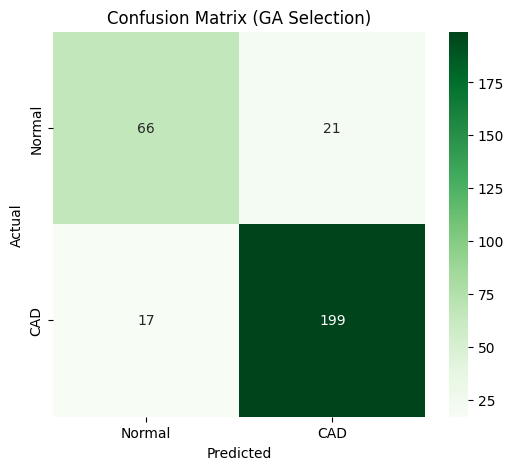

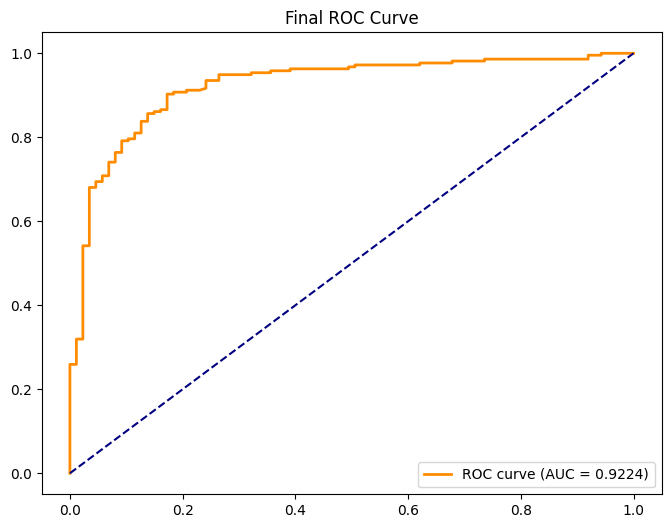

In [6]:
# Classification Report
print("\nDetailed Report:")
print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Cad']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_y_true, all_y_pred), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'CAD'], yticklabels=['Normal', 'CAD'])
plt.title('Confusion Matrix (GA Selection)')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc(fpr, tpr):.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Final ROC Curve'); plt.legend(loc="lower right"); plt.show()

## Conclusion: Optimization and Resource Efficiency

### Summary of the Hybrid GA-SVM Approach
The implementation of a **Genetic Algorithm (GA)** coupled with a **Support Vector Machine (SVM)** has demonstrated a powerful methodology for diagnosing Coronary Artery Disease. By simulating natural evolution, the GA successfully navigated a high-dimensional feature space to identify the most discriminative clinical markers, while the SVM provided a robust decision boundary for classification.

### Resource Saving and Efficiency
The primary advantage of this hybrid approach lies in **Resource Optimization**:
* **Clinical Resource Saving:** The GA reduced the initial feature set (over 50 variables) to a lean, optimal subset. In a clinical setting, this means healthcare providers can focus on a few high-impact tests (e.g., EF-TTE, Age, specific biomarkers) rather than performing an exhaustive and expensive battery of examinations.
* **Computational Efficiency:** By eliminating redundant and noisy features, we significantly reduced the computational load. A smaller feature set leads to faster model training and inference times, making it suitable for real-time diagnostic tools.
* **Cost-Effectiveness:** Fewer required diagnostic tests directly translate to lower healthcare costs for patients and providers, without compromising diagnostic accuracy.

### Performance and Reliability
The final evaluation using **10-Fold Cross-Validation** yielded high scores in **Sensitivity (Recall)** and **AUC-ROC**. This indicates that the model is not only accurate but also reliable in a medical context, where failing to detect a positive CAD case (False Negative) is critical.

### Final Verdict
This project proves that **AI-driven feature selection** is not just about improving accuracy—it is about making healthcare smarter and more sustainable. By integrating evolutionary computing with statistical learning, we have created a framework that balances **high predictive power** with **minimal data requirements**, paving the way for more efficient digital health solutions.